# 03 — Baseline LSTM pour la classification de toxicité (Jigsaw)

**Mini-projet IA Responsable — Phase 1 bis**

Ce notebook entraîne et évalue un modèle BiLSTM (Bidirectional LSTM) sur le corpus *Jigsaw Unintended Bias in Toxicity Classification*, en utilisant **exactement les mêmes splits** que le baseline BERT (`split_ids.json`).

**Objectif** : obtenir les mêmes métriques que le notebook `02_baseline_bert.ipynb` pour permettre la comparaison directe BERT vs LSTM.

**Métriques produites** :
- ROC-AUC global et ECE (calibration),
- Subgroup / BPSN / BNSP AUC pour chaque identité ayant ≥ 500 exemples en test,
- Score Jigsaw final (moyenne arithmétique de l'overall AUC et des 3 moyennes généralisées avec *p* = −5).

---

**Sommaire**

0. Setup et configuration
1. Chargement des données
2. Reconstruction des splits (depuis `split_ids.json`)
3. Construction du vocabulaire
4. Dataset et DataLoader PyTorch
5. Architecture BiLSTM
6. Entraînement
7. Inférence sur le test set
8. Performance globale et calibration
9. Métriques d'équité par identité
10. Visualisations
11. Sauvegarde des artefacts
12. Tableau comparatif BERT vs LSTM

## 0. Setup & Configuration

In [1]:
# Décommenter pour installer les dépendances (Colab/Kaggle).
# !pip -q install torch scikit-learn pandas numpy matplotlib seaborn pyarrow tqdm

In [2]:
import json
import os
import random
import re
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("tab10")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Torch  : {torch.__version__}")

/home/lehoang510/Desktop/Telecom-Paris/S3/Explainable AI/AI-Fairness-Jigsaw/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
GPU    : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM   : 6.1 GB
Torch  : 2.11.0+cu130


In [3]:
# === Chemins ===
DATA_DIR = Path(
    os.environ.get(
        "JIGSAW_DATA_DIR",
        "/home/lehoang510/Desktop/Telecom-Paris/S3/Explainable AI/TP/Project/dataset",
    )
).expanduser().resolve()
TRAIN_CSV = DATA_DIR / "train.csv"

REPORTS_DIR     = Path("../reports").resolve()
SPLITS_DIR      = REPORTS_DIR / "splits"
METRICS_DIR     = REPORTS_DIR / "metrics"
FIGURES_DIR     = REPORTS_DIR / "figures"
CHECKPOINTS_DIR = REPORTS_DIR / "checkpoints" / "baseline_lstm"
for p in (REPORTS_DIR, SPLITS_DIR, METRICS_DIR, FIGURES_DIR, CHECKPOINTS_DIR):
    p.mkdir(parents=True, exist_ok=True)

print(f"DATA_DIR        : {DATA_DIR}")
print(f"TRAIN_CSV       : {TRAIN_CSV} | exists = {TRAIN_CSV.exists()}")
print(f"SPLITS_DIR      : {SPLITS_DIR}")

# === Hyperparamètres LSTM ===
SEED             = 1337
MAX_LEN          = 200       # tokens par commentaire
MAX_VOCAB        = 100_000   # taille du vocabulaire
EMBED_DIM        = 128       # dimension des embeddings
HIDDEN_DIM       = 256       # taille état caché LSTM (par direction)
N_LAYERS         = 2         # nombre de couches LSTM
DROPOUT          = 0.3
BATCH_SIZE_TRAIN = 512
BATCH_SIZE_EVAL  = 1024
LR               = 1e-3
N_EPOCHS         = 3
CLIP_GRAD_NORM   = 1.0

# === Colonnes identités ===
IDENTITY_COLS = [
    "asian", "atheist", "bisexual", "black", "buddhist", "christian", "female",
    "heterosexual", "hindu", "homosexual_gay_or_lesbian",
    "intellectual_or_learning_disability", "jewish", "latino", "male", "muslim",
    "other_disability", "other_gender", "other_race_or_ethnicity", "other_religion",
    "other_sexual_orientation", "physical_disability", "psychiatric_or_mental_illness",
    "transgender", "white",
]
USE_COLS = ["id", "comment_text", "target"] + IDENTITY_COLS

LABEL_THRESHOLD       = 0.5
IDENTITY_THRESHOLD    = 0.5
MIN_TEST_PER_IDENTITY = 500
P_GEN_MEAN            = -5.0

DATA_DIR        : /home/lehoang510/Desktop/Telecom-Paris/S3/Explainable AI/TP/Project/dataset
TRAIN_CSV       : /home/lehoang510/Desktop/Telecom-Paris/S3/Explainable AI/TP/Project/dataset/train.csv | exists = True
SPLITS_DIR      : /home/lehoang510/Desktop/Telecom-Paris/S3/Explainable AI/AI-Fairness-Jigsaw/reports/splits


In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Seed : {SEED}")

Seed : 1337


## 1. Chargement des données

In [5]:
assert TRAIN_CSV.exists(), (
    f"Fichier introuvable: {TRAIN_CSV}\n"
    f"Définir JIGSAW_DATA_DIR ou modifier DATA_DIR dans la cellule de config."
)

print(f"Lecture de {TRAIN_CSV} …")
df = pd.read_csv(TRAIN_CSV, usecols=USE_COLS)
print(f"Total lignes : {len(df):,}")

# Étiquette binaire
df["label"] = (df["target"].fillna(0) >= LABEL_THRESHOLD).astype(int)

# Colonnes identité binaires
for c in IDENTITY_COLS:
    df[c + "_bin"] = (df[c].fillna(0) >= IDENTITY_THRESHOLD).astype(int)
df["any_identity"] = df[[c + "_bin" for c in IDENTITY_COLS]].max(axis=1)

print(f"Taux toxique global : {df['label'].mean():.4f}")
print(f"Taux any_identity   : {df['any_identity'].mean():.4f}")

Lecture de /home/lehoang510/Desktop/Telecom-Paris/S3/Explainable AI/TP/Project/dataset/train.csv …
Total lignes : 1,804,874
Taux toxique global : 0.0800
Taux any_identity   : 0.0944


## 2. Reconstruction des splits depuis `split_ids.json`

On recharge exactement les mêmes IDs que le notebook BERT pour garantir la **comparabilité absolue** des métriques.

In [6]:
split_path = SPLITS_DIR / "split_ids.json"
assert split_path.exists(), (
    f"Fichier split_ids.json introuvable : {split_path}\n"
    f"Lancer d'abord le notebook 02_baseline_bert.ipynb."
)

print(f"Chargement de {split_path} …")
with open(split_path, "r", encoding="utf-8") as f:
    splits_payload = json.load(f)

print(f"  Seed utilisé : {splits_payload['seed']}")
print(f"  N rows total : {splits_payload['n_rows_used']:,}")
print(f"  Train : {len(splits_payload['train']):,}")
print(f"  Val   : {len(splits_payload['val']):,}")
print(f"  Test  : {len(splits_payload['test']):,}")

train_ids = set(splits_payload["train"])
val_ids   = set(splits_payload["val"])
test_ids  = set(splits_payload["test"])

train_df = df[df["id"].isin(train_ids)].reset_index(drop=True)
val_df   = df[df["id"].isin(val_ids)].reset_index(drop=True)
test_df  = df[df["id"].isin(test_ids)].reset_index(drop=True)

print(f"\nSplits reconstruits :")
print(f"  Train : {len(train_df):>9,} | Val : {len(val_df):>8,} | Test : {len(test_df):>8,}")
print("\nTaux par split :")
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"  {name:5s} | toxic={d['label'].mean():.4f} | any_identity={d['any_identity'].mean():.4f}")

Chargement de /home/lehoang510/Desktop/Telecom-Paris/S3/Explainable AI/AI-Fairness-Jigsaw/reports/splits/split_ids.json …
  Seed utilisé : 1337
  N rows total : 1,804,874
  Train : 1,443,897
  Val   : 180,486
  Test  : 180,491

Splits reconstruits :
  Train : 1,443,897 | Val :  180,486 | Test :  180,491

Taux par split :
  train | toxic=0.0800 | any_identity=0.0944
  val   | toxic=0.0800 | any_identity=0.0944
  test  | toxic=0.0800 | any_identity=0.0944


## 3. Construction du vocabulaire

Tokenisation simple (minuscules + regex) sur le train set uniquement. Vocabulaire limité à `MAX_VOCAB = 100 000` tokens les plus fréquents. Les tokens inconnus (OOV) sont mappés sur `<UNK>`, le padding sur `<PAD>` (index 0).

In [7]:
_TOKEN_RE = re.compile(r"[a-z0-9']+|[^a-z0-9\s]")

def simple_tokenize(text: str) -> list[str]:
    """Lowercase + split on word/punctuation boundaries."""
    return _TOKEN_RE.findall(str(text).lower())


print("Construction du vocabulaire (train uniquement) …")
counter: Counter = Counter()
for text in tqdm(train_df["comment_text"].fillna(""), desc="vocab"):
    counter.update(simple_tokenize(text))

print(f"Tokens distincts dans le train : {len(counter):,}")

PAD_TOKEN, UNK_TOKEN = "<PAD>", "<UNK>"
vocab = [PAD_TOKEN, UNK_TOKEN] + [tok for tok, _ in counter.most_common(MAX_VOCAB - 2)]
token2idx = {tok: i for i, tok in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
PAD_IDX, UNK_IDX = 0, 1

print(f"Taille du vocabulaire effectif : {VOCAB_SIZE:,}")
print(f"Top-10 tokens : {[t for t,_ in counter.most_common(10)]}")

Construction du vocabulaire (train uniquement) …


vocab: 100%|██████████| 1443897/1443897 [00:15<00:00, 93338.98it/s]


Tokens distincts dans le train : 321,933
Taille du vocabulaire effectif : 100,000
Top-10 tokens : ['.', 'the', ',', 'to', 'and', 'of', 'a', 'is', 'in', 'that']


## 4. Dataset et DataLoader PyTorch

In [8]:
class ToxicityDataset(Dataset):
    """Converts texts to padded integer sequences for LSTM input."""

    def __init__(self, texts: list[str], labels: list[int],
                 token2idx: dict[str, int], max_len: int) -> None:
        self.labels = labels
        self.sequences = [
            self._encode(t, token2idx, max_len) for t in tqdm(texts, desc="encode", leave=False)
        ]

    @staticmethod
    def _encode(text: str, token2idx: dict[str, int], max_len: int) -> torch.Tensor:
        tokens = simple_tokenize(text)[:max_len]
        ids = [token2idx.get(t, UNK_IDX) for t in tokens]
        pad = max_len - len(ids)
        ids = ids + [PAD_IDX] * pad
        return torch.tensor(ids, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.sequences[idx], torch.tensor(self.labels[idx], dtype=torch.float32)


print("Encodage train …")
train_ds = ToxicityDataset(
    train_df["comment_text"].fillna("").tolist(),
    train_df["label"].tolist(),
    token2idx, MAX_LEN,
)
print("Encodage val …")
val_ds = ToxicityDataset(
    val_df["comment_text"].fillna("").tolist(),
    val_df["label"].tolist(),
    token2idx, MAX_LEN,
)
print("Encodage test …")
test_ds = ToxicityDataset(
    test_df["comment_text"].fillna("").tolist(),
    test_df["label"].tolist(),
    token2idx, MAX_LEN,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_TRAIN, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE_EVAL,  shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE_EVAL,  shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"\nTrain batches : {len(train_loader):,} | Val : {len(val_loader):,} | Test : {len(test_loader):,}")

Encodage train …


Encodage val …


Encodage test …



Train batches : 2,821 | Val : 177 | Test : 177


## 5. Architecture BiLSTM

Architecture : **Embedding → Dropout → BiLSTM (2 couches) → Pooling (mean + max) → Dropout → Linear → logit**

La concaténation du pooling moyen et du pooling max est une heuristique classique qui améliore la capture du signal global et des pics locaux.

In [9]:
class BiLSTMClassifier(nn.Module):
    """
    Bidirectional LSTM for binary text classification.
    Output: single logit (use sigmoid to get probability).
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        n_layers: int,
        dropout: float,
        pad_idx: int,
    ) -> None:
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.emb_drop = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=n_layers,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0,
            batch_first=True,
        )
        self.fc_drop = nn.Dropout(dropout)
        # mean-pool + max-pool => 2 * 2 * hidden_dim
        self.fc = nn.Linear(2 * 2 * hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (batch, seq_len)
        emb = self.emb_drop(self.embedding(x))          # (batch, seq_len, embed_dim)
        lstm_out, _ = self.lstm(emb)                    # (batch, seq_len, 2*hidden_dim)
        mean_pool = lstm_out.mean(dim=1)                # (batch, 2*hidden_dim)
        max_pool  = lstm_out.max(dim=1).values          # (batch, 2*hidden_dim)
        pooled = torch.cat([mean_pool, max_pool], dim=1)  # (batch, 4*hidden_dim)
        out = self.fc(self.fc_drop(pooled))             # (batch, 1)
        return out.squeeze(-1)                          # (batch,)


model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Paramètres modèle : {n_params/1e6:.2f} M")
print(model)

Paramètres modèle : 15.17 M
BiLSTMClassifier(
  (embedding): Embedding(100000, 128, padding_idx=0)
  (emb_drop): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc_drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=1024, out_features=1, bias=True)
)


## 6. Entraînement

Même perte BCE que BERT (BCEWithLogitsLoss). Optimiseur Adam avec `lr=1e-3`. Scheduleur cosine annealing. Early stopping basé sur la ROC-AUC du val set.

In [10]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
scaler    = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


def train_epoch(model, loader, optimizer, criterion, scaler, clip_norm):
    model.train()
    total_loss, n = 0.0, 0
    pbar = tqdm(loader, desc="  train", leave=False)
    for seqs, labels in pbar:
        seqs, labels = seqs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(seqs)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * len(labels)
        n += len(labels)
        pbar.set_postfix(loss=f"{total_loss/n:.4f}")
    return total_loss / n


@torch.inference_mode()
def evaluate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for seqs, labels in tqdm(loader, desc="  eval", leave=False):
        seqs = seqs.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(seqs)
        all_logits.append(logits.cpu().numpy())
        all_labels.append(labels.numpy())
    logits_arr = np.concatenate(all_logits)
    labels_arr = np.concatenate(all_labels)
    probs = 1 / (1 + np.exp(-logits_arr))
    auc = float(roc_auc_score(labels_arr, probs))
    loss = float(nn.functional.binary_cross_entropy_with_logits(
        torch.tensor(logits_arr), torch.tensor(labels_arr)
    ))
    return auc, loss, probs, logits_arr, labels_arr


best_val_auc  = 0.0
best_ckpt_path = CHECKPOINTS_DIR / "best_model.pt"
history = []

print(f"Démarrage de l'entraînement ({N_EPOCHS} epochs) …")
for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, scaler, CLIP_GRAD_NORM)
    val_auc, val_loss, _, _, _ = evaluate(model, val_loader)
    scheduler.step()
    lr_current = scheduler.get_last_lr()[0]
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_auc": val_auc})
    flag = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), best_ckpt_path)
        flag = " ← best"
    print(f"Epoch {epoch}/{N_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_AUC={val_auc:.4f} | lr={lr_current:.2e}{flag}")

print(f"\nMeilleur val AUC : {best_val_auc:.4f} → {best_ckpt_path}")

Démarrage de l'entraînement (3 epochs) …


Epoch 1/3 | train_loss=0.1631 | val_loss=0.1298 | val_AUC=0.9521 | lr=7.50e-04 ← best


Epoch 2/3 | train_loss=0.1297 | val_loss=0.1224 | val_AUC=0.9585 | lr=2.50e-04 ← best


Epoch 3/3 | train_loss=0.1205 | val_loss=0.1209 | val_AUC=0.9606 | lr=0.00e+00 ← best

Meilleur val AUC : 0.9606 → /home/lehoang510/Desktop/Telecom-Paris/S3/Explainable AI/AI-Fairness-Jigsaw/reports/checkpoints/baseline_lstm/best_model.pt


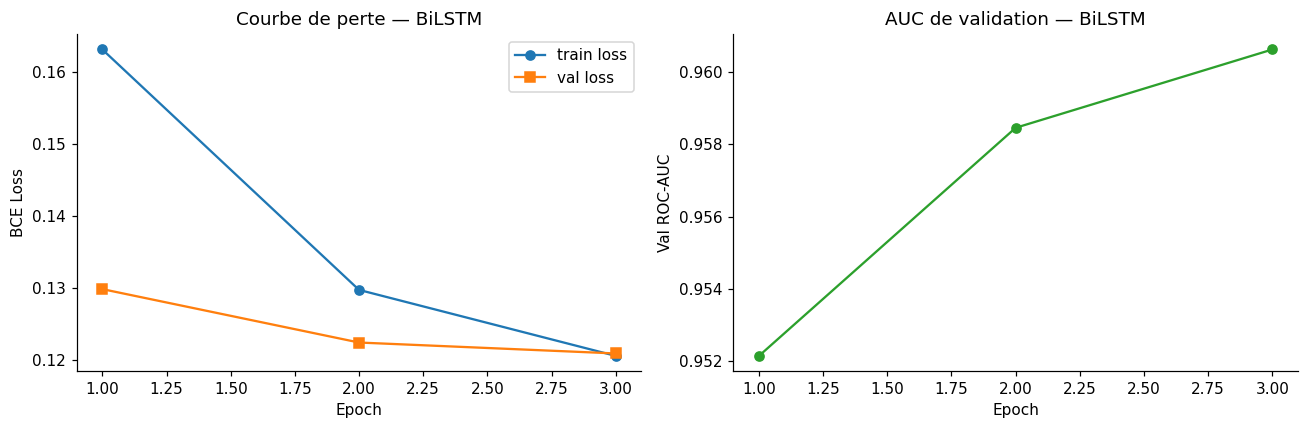

In [11]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="train loss")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"],   marker="s", label="val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Courbe de perte — BiLSTM")
axes[0].legend()
axes[1].plot(hist_df["epoch"], hist_df["val_auc"], marker="o", color="tab:green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val ROC-AUC")
axes[1].set_title("AUC de validation — BiLSTM")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lstm_training_curves.png", bbox_inches="tight")
plt.show()

## 7. Inférence sur le test set

On charge le meilleur checkpoint (meilleur val AUC) pour l'inférence finale.

In [12]:
best_ckpt_path = CHECKPOINTS_DIR / "best_model.pt"

print(f"Chargement du meilleur modèle : {best_ckpt_path}")
model.load_state_dict(torch.load(best_ckpt_path, map_location=DEVICE))

print(f"Inférence sur {len(test_df):,} commentaires …")
_, _, probs_test, logits_test, y_true = evaluate(model, test_loader)

test_predictions = test_df.copy()
test_predictions["pred_prob"]  = probs_test
test_predictions["pred_logit"] = logits_test
pred_path = METRICS_DIR / "test_predictions_lstm.parquet"
test_predictions.to_parquet(pred_path, index=False)
print(f"Prédictions écrites : {pred_path}")

Chargement du meilleur modèle : /home/lehoang510/Desktop/Telecom-Paris/S3/Explainable AI/AI-Fairness-Jigsaw/reports/checkpoints/baseline_lstm/best_model.pt
Inférence sur 180,491 commentaires …


Prédictions écrites : /home/lehoang510/Desktop/Telecom-Paris/S3/Explainable AI/AI-Fairness-Jigsaw/reports/metrics/test_predictions_lstm.parquet


## 8. Performance globale et calibration

In [13]:
def expected_calibration_error(y_true, y_prob, n_bins: int = 15) -> float:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= 0.5).astype(int)
    conf = np.where(y_pred == 1, y_prob, 1.0 - y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece, n = 0.0, len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf >= lo) & (conf < hi if i < n_bins - 1 else conf <= hi)
        if not np.any(mask):
            continue
        acc = float(np.mean(y_pred[mask] == y_true[mask]))
        avg_conf = float(np.mean(conf[mask]))
        ece += (np.sum(mask) / n) * abs(acc - avg_conf)
    return float(ece)


overall_auc = float(roc_auc_score(y_true, probs_test))
ece         = expected_calibration_error(y_true, probs_test, n_bins=15)
y_pred_bin  = (probs_test >= 0.5).astype(int)
accuracy    = float(np.mean(y_pred_bin == y_true.astype(int)))

print(f"Overall ROC-AUC : {overall_auc:.4f}")
print(f"ECE (15 bins)   : {ece:.4f}")
print(f"Accuracy (>=.5) : {accuracy:.4f}")

Overall ROC-AUC : 0.9604
ECE (15 bins)   : 0.0074
Accuracy (>=.5) : 0.9527


## 9. Métriques d'équité par identité

Mêmes métriques que le notebook BERT (Borkan et al., 2019) : Subgroup AUC, BPSN AUC, BNSP AUC, moyennes généralisées avec *p* = −5.

In [14]:
def safe_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    y_true = np.asarray(y_true).astype(int)
    if y_true.size == 0 or y_true.min() == y_true.max():
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


def compute_identity_aucs(y_true: np.ndarray, y_pred: np.ndarray, sub_mask: np.ndarray) -> dict:
    sub = sub_mask.astype(bool)
    bg  = ~sub
    sg = safe_auc(y_true[sub], y_pred[sub])
    bpsn_mask = (sub & (y_true == 0)) | (bg & (y_true == 1))
    bnsp_mask = (sub & (y_true == 1)) | (bg & (y_true == 0))
    return {
        "subgroup_auc": sg,
        "bpsn_auc":     safe_auc(y_true[bpsn_mask], y_pred[bpsn_mask]),
        "bnsp_auc":     safe_auc(y_true[bnsp_mask], y_pred[bnsp_mask]),
        "n_subgroup":   int(sub.sum()),
    }


y_true_int = y_true.astype(int)
records = []
for col in IDENTITY_COLS:
    sub_mask = test_df[col + "_bin"].to_numpy().astype(bool)
    n_sub = int(sub_mask.sum())
    if n_sub < MIN_TEST_PER_IDENTITY:
        continue
    aucs = compute_identity_aucs(y_true_int, probs_test, sub_mask)
    records.append({"identity": col, **aucs})

fairness_df = pd.DataFrame(records).sort_values("subgroup_auc").reset_index(drop=True)
print(f"Identités retenues (n_test ≥ {MIN_TEST_PER_IDENTITY}) : {len(fairness_df)}\n")
print(fairness_df.to_string(index=False))

Identités retenues (n_test ≥ 500) : 8

                 identity  subgroup_auc  bpsn_auc  bnsp_auc  n_subgroup
                    black      0.824389  0.819893  0.969500        1496
homosexual_gay_or_lesbian      0.842789  0.831756  0.971166        1141
                    white      0.845074  0.839763  0.969415        2551
                   muslim      0.845409  0.864013  0.962681        2151
                   jewish      0.898425  0.904945  0.957918         788
                   female      0.919206  0.924757  0.960395        5356
                     male      0.919482  0.915580  0.965884        4467
                christian      0.925919  0.947860  0.943782        4017


In [15]:
def generalized_mean(values, p: float = -5.0) -> float:
    arr = np.asarray([v for v in values if np.isfinite(v)], dtype=float)
    if arr.size == 0:
        return float("nan")
    return float(np.power(np.mean(np.power(arr, p)), 1.0 / p))


gm_sub  = generalized_mean(fairness_df["subgroup_auc"], p=P_GEN_MEAN)
gm_bpsn = generalized_mean(fairness_df["bpsn_auc"],     p=P_GEN_MEAN)
gm_bnsp = generalized_mean(fairness_df["bnsp_auc"],     p=P_GEN_MEAN)
final_score = float(np.nanmean([overall_auc, gm_sub, gm_bpsn, gm_bnsp]))

print(f"Moyennes généralisées (p = {P_GEN_MEAN}) :")
print(f"  Subgroup : {gm_sub:.4f}")
print(f"  BPSN     : {gm_bpsn:.4f}")
print(f"  BNSP     : {gm_bnsp:.4f}")
print(f"\nOverall ROC-AUC    : {overall_auc:.4f}")
print(f"Jigsaw final score : {final_score:.4f}")
print(f"  = (overall + gm_sub + gm_bpsn + gm_bnsp) / 4")

Moyennes généralisées (p = -5.0) :
  Subgroup : 0.8723
  BPSN     : 0.8742
  BNSP     : 0.9624

Overall ROC-AUC    : 0.9604
Jigsaw final score : 0.9173
  = (overall + gm_sub + gm_bpsn + gm_bnsp) / 4


## 10. Visualisations

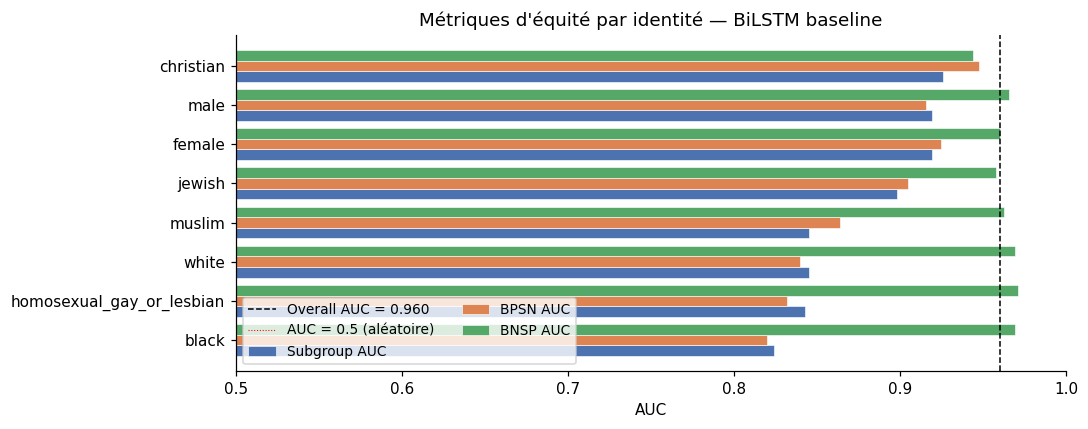

In [16]:
fig, ax = plt.subplots(figsize=(10, max(4, 0.32 * len(fairness_df))))
df_plot = fairness_df.set_index("identity")[["subgroup_auc", "bpsn_auc", "bnsp_auc"]].copy()
df_plot = df_plot.sort_values("subgroup_auc")
y = np.arange(len(df_plot))
w = 0.27
ax.barh(y - w, df_plot["subgroup_auc"], w, label="Subgroup AUC", color="#4C72B0", edgecolor="white", lw=0.4)
ax.barh(y,     df_plot["bpsn_auc"],     w, label="BPSN AUC",     color="#DD8452", edgecolor="white", lw=0.4)
ax.barh(y + w, df_plot["bnsp_auc"],     w, label="BNSP AUC",     color="#55A868", edgecolor="white", lw=0.4)
ax.axvline(overall_auc, color="black", lw=1.0, ls="--", label=f"Overall AUC = {overall_auc:.3f}")
ax.axvline(0.5, color="red", lw=0.7, ls=":", label="AUC = 0.5 (aléatoire)")
ax.set_yticks(y); ax.set_yticklabels(df_plot.index)
ax.set_xlim(0.5, 1.0); ax.set_xlabel("AUC")
ax.set_title("Métriques d'équité par identité — BiLSTM baseline")
ax.legend(loc="lower left", fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lstm_per_identity_aucs.png", bbox_inches="tight")
plt.show()

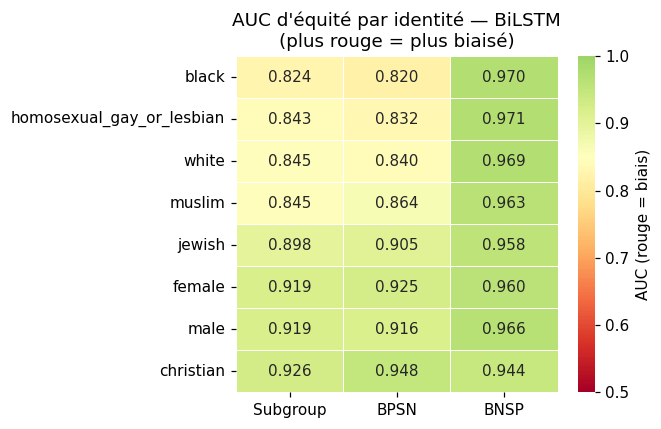

In [17]:
heat = fairness_df.set_index("identity")[["subgroup_auc", "bpsn_auc", "bnsp_auc"]].copy()
heat.columns = ["Subgroup", "BPSN", "BNSP"]
heat = heat.sort_values("Subgroup")

fig, ax = plt.subplots(figsize=(6, max(4, 0.30 * len(heat))))
sns.heatmap(
    heat, annot=True, fmt=".3f",
    cmap="RdYlGn", vmin=0.5, vmax=1.0, center=0.85,
    ax=ax, cbar_kws={"label": "AUC (rouge = biais)"},
    linewidths=0.4,
)
ax.set_title("AUC d'équité par identité — BiLSTM\n(plus rouge = plus biaisé)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lstm_auc_heatmap.png", bbox_inches="tight")
plt.show()

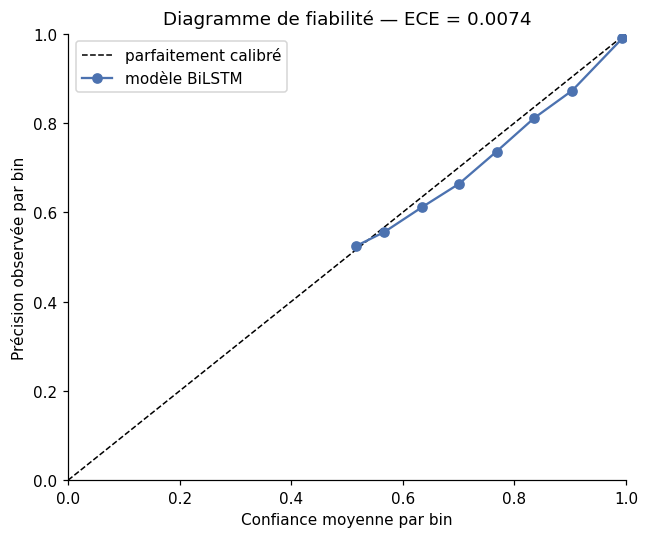

In [18]:
n_bins = 15
y_true_int_cal = y_true.astype(int)
y_pred_cal = (probs_test >= 0.5).astype(int)
conf = np.where(y_pred_cal == 1, probs_test, 1 - probs_test)
bins = np.linspace(0, 1, n_bins + 1)
bin_acc, bin_conf, bin_n = [], [], []
for i in range(n_bins):
    lo, hi = bins[i], bins[i + 1]
    mask = (conf >= lo) & (conf < hi if i < n_bins - 1 else conf <= hi)
    if mask.sum() == 0:
        bin_acc.append(np.nan); bin_conf.append(np.nan); bin_n.append(0)
    else:
        bin_acc.append(float((y_pred_cal[mask] == y_true_int_cal[mask]).mean()))
        bin_conf.append(float(conf[mask].mean()))
        bin_n.append(int(mask.sum()))

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="parfaitement calibré")
ax.plot(bin_conf, bin_acc, marker="o", lw=1.5, color="#4C72B0", label="modèle BiLSTM")
ax.set_xlabel("Confiance moyenne par bin")
ax.set_ylabel("Précision observée par bin")
ax.set_title(f"Diagramme de fiabilité — ECE = {ece:.4f}")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lstm_reliability.png", bbox_inches="tight")
plt.show()

## 11. Sauvegarde des artefacts

In [19]:
results = {
    "model_name": "BiLSTM",
    "seed": SEED,
    "n_rows_used": int(len(df)),
    "n_train": int(len(train_df)), "n_val": int(len(val_df)), "n_test": int(len(test_df)),
    "max_length": MAX_LEN,
    "vocab_size": VOCAB_SIZE,
    "embed_dim": EMBED_DIM,
    "hidden_dim": HIDDEN_DIM,
    "n_layers": N_LAYERS,
    "dropout": DROPOUT,
    "epochs": N_EPOCHS,
    "batch_size_train": BATCH_SIZE_TRAIN,
    "learning_rate": LR,
    "n_params_M": round(sum(p.numel() for p in model.parameters()) / 1e6, 2),
    "overall_auc": float(overall_auc),
    "accuracy_at_0.5": float(accuracy),
    "ece_15bins": float(ece),
    "jigsaw_final_score": float(final_score),
    "generalized_mean_p": P_GEN_MEAN,
    "generalized_mean": {
        "subgroup_auc": float(gm_sub),
        "bpsn_auc":     float(gm_bpsn),
        "bnsp_auc":     float(gm_bnsp),
    },
    "min_test_per_identity": MIN_TEST_PER_IDENTITY,
    "n_identities_used": int(len(fairness_df)),
    "per_identity": fairness_df.set_index("identity").to_dict(orient="index"),
    "training_history": history,
}

metrics_path = METRICS_DIR / "lstm_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)
print(f"Métriques sauvegardées : {metrics_path}")

print("\n=== RÉCAPITULATIF BASELINE BiLSTM ===")
print(f"  N rows                : {results['n_rows_used']:,}")
print(f"  Paramètres            : {results['n_params_M']} M")
print(f"  Overall AUC           : {results['overall_auc']:.4f}")
print(f"  ECE (15 bins)         : {results['ece_15bins']:.4f}")
print(f"  Jigsaw final score    : {results['jigsaw_final_score']:.4f}")
print(f"  Identités évaluées    : {results['n_identities_used']}")
print(f"  Min Subgroup AUC      : {fairness_df['subgroup_auc'].min():.4f}  ({fairness_df.iloc[0]['identity']})")
print(f"  Min BPSN AUC          : {fairness_df['bpsn_auc'].min():.4f}  ({fairness_df.loc[fairness_df['bpsn_auc'].idxmin(), 'identity']})")
print(f"  Min BNSP AUC          : {fairness_df['bnsp_auc'].min():.4f}  ({fairness_df.loc[fairness_df['bnsp_auc'].idxmin(), 'identity']})")

Métriques sauvegardées : /home/lehoang510/Desktop/Telecom-Paris/S3/Explainable AI/AI-Fairness-Jigsaw/reports/metrics/lstm_metrics.json

=== RÉCAPITULATIF BASELINE BiLSTM ===
  N rows                : 1,804,874
  Paramètres            : 15.17 M
  Overall AUC           : 0.9604
  ECE (15 bins)         : 0.0074
  Jigsaw final score    : 0.9173
  Identités évaluées    : 8
  Min Subgroup AUC      : 0.8244  (black)
  Min BPSN AUC          : 0.8199  (black)
  Min BNSP AUC          : 0.9438  (christian)


## 12. Tableau comparatif BERT vs BiLSTM

Chargement du fichier `baseline_metrics.json` (BERT) pour comparaison directe.

In [20]:
bert_path = METRICS_DIR / "baseline_metrics.json"

if not bert_path.exists():
    print(f"[INFO] {bert_path} introuvable — lancer d'abord 02_baseline_bert.ipynb.")
else:
    with open(bert_path, "r", encoding="utf-8") as f:
        bert_results = json.load(f)

    # --- Métriques globales ---
    global_compare = pd.DataFrame([
        {
            "Modèle": "BERT (bert-base-uncased)",
            "Paramètres (M)": 109.5,
            "Overall AUC": bert_results["overall_auc"],
            "ECE (15 bins)": bert_results["ece_15bins"],
            "Accuracy": bert_results["accuracy_at_0.5"],
            "GM Subgroup AUC": bert_results["generalized_mean"]["subgroup_auc"],
            "GM BPSN AUC":     bert_results["generalized_mean"]["bpsn_auc"],
            "GM BNSP AUC":     bert_results["generalized_mean"]["bnsp_auc"],
            "Jigsaw Score":    bert_results["jigsaw_final_score"],
        },
        {
            "Modèle": "BiLSTM (baseline)",
            "Paramètres (M)": results["n_params_M"],
            "Overall AUC": results["overall_auc"],
            "ECE (15 bins)": results["ece_15bins"],
            "Accuracy": results["accuracy_at_0.5"],
            "GM Subgroup AUC": results["generalized_mean"]["subgroup_auc"],
            "GM BPSN AUC":     results["generalized_mean"]["bpsn_auc"],
            "GM BNSP AUC":     results["generalized_mean"]["bnsp_auc"],
            "Jigsaw Score":    results["jigsaw_final_score"],
        },
    ])

    print("=== TABLEAU COMPARATIF GLOBAL ===")
    print(global_compare.set_index("Modèle").T.to_string())

    # --- Métriques par identité ---
    bert_id  = pd.DataFrame(bert_results["per_identity"]).T.reset_index().rename(columns={"index": "identity"})
    lstm_id  = fairness_df[["identity", "subgroup_auc", "bpsn_auc", "bnsp_auc", "n_subgroup"]].copy()

    merged_id = bert_id[["identity", "subgroup_auc", "bpsn_auc", "bnsp_auc"]].merge(
        lstm_id[["identity", "subgroup_auc", "bpsn_auc", "bnsp_auc"]],
        on="identity", suffixes=("_BERT", "_LSTM"),
    )
    merged_id["Δsubgroup"] = merged_id["subgroup_auc_LSTM"] - merged_id["subgroup_auc_BERT"]
    merged_id["ΔBPSN"]     = merged_id["bpsn_auc_LSTM"]     - merged_id["bpsn_auc_BERT"]
    merged_id["ΔBNSP"]     = merged_id["bnsp_auc_LSTM"]     - merged_id["bnsp_auc_BERT"]

    print("\n=== COMPARATIF PAR IDENTITÉ (LSTM - BERT, Δ > 0 = LSTM meilleur) ===")
    print(merged_id.set_index("identity")[["Δsubgroup", "ΔBPSN", "ΔBNSP"]].to_string(float_format="{:+.4f}".format))

[INFO] /home/lehoang510/Desktop/Telecom-Paris/S3/Explainable AI/AI-Fairness-Jigsaw/reports/metrics/baseline_metrics.json introuvable — lancer d'abord 02_baseline_bert.ipynb.


In [21]:
if bert_path.exists():
    fig, axes = plt.subplots(1, 3, figsize=(15, max(4, 0.35 * len(merged_id))), sharey=True)
    metrics_cols = [
        ("subgroup_auc", "Subgroup AUC"),
        ("bpsn_auc", "BPSN AUC"),
        ("bnsp_auc", "BNSP AUC"),
    ]
    identities = merged_id.set_index("identity").sort_values("subgroup_auc_BERT").index
    y = np.arange(len(identities))
    for ax, (col, title) in zip(axes, metrics_cols):
        bert_vals = merged_id.set_index("identity").loc[identities, col + "_BERT"]
        lstm_vals = merged_id.set_index("identity").loc[identities, col + "_LSTM"]
        ax.barh(y - 0.18, bert_vals, 0.35, label="BERT", color="#4C72B0", alpha=0.85)
        ax.barh(y + 0.18, lstm_vals, 0.35, label="BiLSTM", color="#DD8452", alpha=0.85)
        ax.set_yticks(y); ax.set_yticklabels(identities)
        ax.set_xlim(0.5, 1.0); ax.set_xlabel("AUC")
        ax.set_title(title)
        ax.legend(fontsize=8)
    fig.suptitle("BERT vs BiLSTM — Métriques d'équité par identité", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "bert_vs_lstm_fairness.png", bbox_inches="tight")
    plt.show()
else:
    print("[INFO] baseline_metrics.json manquant — visualisation comparative ignorée.")

[INFO] baseline_metrics.json manquant — visualisation comparative ignorée.
